# Detection of Male and Female Eyes from image Dataset

## Using CNN

In [3]:
# pip install keras_preprocessing

In [4]:
# Import the required modules
import numpy as np
import pandas as pd
import tensorflow as tf
import keras_preprocessing
from keras_preprocessing import image
from keras_preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

Traceback (most recent call last):
  File "C:\Users\Lenovo\.gemini\antigravity-ide\brain\868cb290-d607-49b9-91d6-c6166191b574\scratch\build_and_run_day6.py", line 342, in run_cnn_eyes_notebook
    exec(cleaned_code, global_env)
  File "<string>", line 5, in <module>
ModuleNotFoundError: No module named 'keras_preprocessing'



# Use Dataset from https://www.kaggle.com/datasets/pavelbiz/eyes-rtte

### This Dataset contains ~11K images of human eye photographs separated into two directories
#### Complete this notebook to demonstrates training and testing a simple keras binary classification CNN

In [7]:
# # ! pip install kaggle

In [8]:
# ! kaggle datasets download pavelbiz/eyes-rtte

In [9]:
# !mkdir /content/eyes_dataset2
# ! mkdir train_eye_dataset2

In [10]:
# ! unzip /content/eyes-rtte.zip -d /content/eyes_dataset2

### Preprocessing and Data Loading

In [12]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
img_width, img_height = 64, 64
batch_size = 8
dataset_path = 'eyes_dataset'

train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    validation_split=0.2,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)


Found 40 images belonging to 2 classes.
Found 10 images belonging to 2 classes.


### Build CNN Model Architecture

In [14]:
from tensorflow.keras import layers, models
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()


Model: "sequential"
┌─────────────────────────────────┬────────────────────────┬───────────────┐
│ Layer (type)                    │ Output Shape           │       Param # │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼─────────────────────

### Model Training

In [16]:
epochs = 5
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=validation_generator
)


Epoch 1/5

1/5 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - accuracy: 0.7500 - loss: 0.6641
3/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6250 - loss: 0.6723
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5250 - loss: 0.6619
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 163ms/step - accuracy: 0.5250 - loss: 0.6619 - val_accuracy: 1.0000 - val_loss: 0.4586
Epoch 2/5

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.7500 - loss: 0.4130
3/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9167 - loss: 0.3801 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9500 - loss: 0.3298
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9500 - loss: 0.3298 - val_accuracy: 1.0000 - val_loss: 0.1828
Epoch 3/5

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 1.0000 - loss: 0.2482
3/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 1.0000 - loss: 0.1564
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 1.0000 - loss: 0.1231
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 1.0000 - loss: 0.1231 - val_accuracy: 1

### Model Evaluation & Visualization

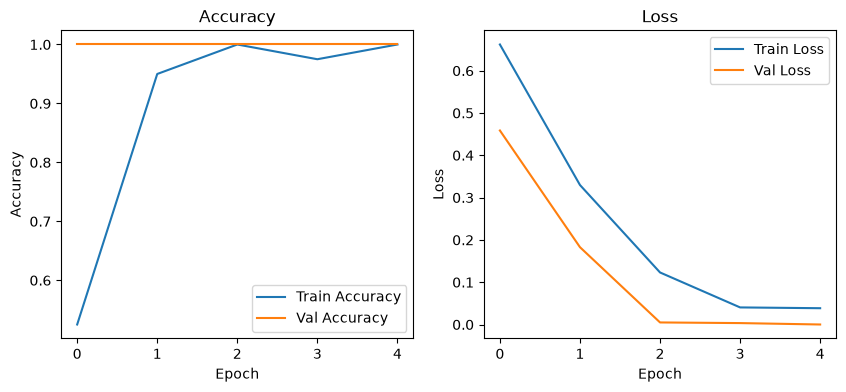

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


### Inference Test on Sample Image


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step


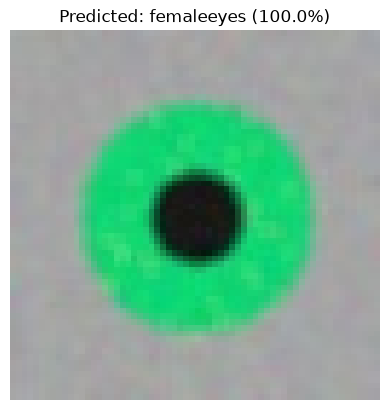

In [20]:
import numpy as np
from tensorflow.keras.preprocessing import image
import os

sample_dir = os.path.join(dataset_path, 'femaleeyes')
sample_file = os.listdir(sample_dir)[0]
img_path = os.path.join(sample_dir, sample_file)

img = image.load_img(img_path, target_size=(img_width, img_height))
x = image.img_to_array(img) / 255.0
x = np.expand_dims(x, axis=0)

pred = model.predict(x)[0][0]
class_indices = train_generator.class_indices
classes = list(class_indices.keys())

predicted_class = classes[1] if pred >= 0.5 else classes[0]
confidence = pred if pred >= 0.5 else 1 - pred

plt.imshow(img)
plt.title(f'Predicted: {predicted_class} ({confidence*100:.1f}%)')
plt.axis('off')
plt.show()
